# A Statistical Analysis of Vowel Inventories of World Languages

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("phoible.csv", low_memory=False)
df.head()

,InventoryID,Glottocode,ISO6393,LanguageName,SpecificDialect,GlyphID,Phoneme,Allophones,Marginal,SegmentClass,...,retractedTongueRoot,advancedTongueRoot,periodicGlottalSource,epilaryngealSource,spreadGlottis,constrictedGlottis,fortis,raisedLarynxEjective,loweredLarynxImplosive,click
0,1,kore1280,kor,Korean,NaN,0061,a,a,NaN,vowel,...,-,-,+,-,-,-,0,-,-,0
1,1,kore1280,kor,Korean,NaN,0061+02D0,aː,aː,NaN,vowel,...,-,-,+,-,-,-,0,-,-,0
2,1,kore1280,kor,Korean,NaN,00E6,æ,ɛ æ,NaN,vowel,...,-,-,+,-,-,-,0,-,-,0
3,1,kore1280,kor,Korean,NaN,00E6+02D0,æː,æː,NaN,vowel,...,-,-,+,-,-,-,0,-,-,0
4,1,kore1280,kor,Korean,NaN,0065,e,e,NaN,vowel,...,-,-,+,-,-,-,0,-,-,0


## Question 2

In [4]:
# Q2: To find the number of rows, inventories, and languages in the dataset
n_rows = len(df)
n_inventories = df['InventoryID'].nunique()
n_languages = df['Glottocode'].nunique()

print("Rows:", n_rows)
print("Inventories:", n_inventories)
print("Languages:", n_languages)

Rows: 105467
Inventories: 3020
Languages: 2184


In [5]:
missing = df[df["Glottocode"].isna()]

print("Rows without Glottocode:", len(missing))
print("Inventories without Glottocode:", missing["InventoryID"].nunique())

Rows without Glottocode: 64
Inventories without Glottocode: 2


In [6]:
missing[["InventoryID", "LanguageName"]].drop_duplicates()

,InventoryID,LanguageName
80964,2281,Modern Aramaic
98581,2729,Djindewal


There are 105,467 rows, 3,020 distinct inventories, and 2,184 distinct languages. These numbers differ because each row represents one phoneme in an inventory, while a single language may be represented by more than one inventory from different descriptions.

Not every inventory has a Glottocode. I found 64 rows without a Glottocode, corresponding to two inventories: Modern Aramaic, and Djindewal. By default, pandas.groupby() drops missing grouping values, so these two inventories are silently excluded when I group by Glottocode in Q4.

## Question 3

Several standards exist because different needs developed over time, so they serve different purposes and have different levels of coverage. For example, ISO 639-1 uses two-letter codes and mainly covers major languages, ISO 639-2 uses three-letter codes and was developed mainly for bibliographic and terminological purposes, while while ISO 639-3 provides much broader coverage of individual languages..

Linguists introduced Glottocodes to provide unique and persistent identifiers not only for languages, but also for dialects and language families. This is useful for cross-linguistic databases because language names can be ambiguous, and classifications may change over time.
I think it is a useful system because the identifiers remain stable even when classifications change, so we can identify and link linguistic varieties more consistently across different databases.

## Question 4

In [7]:
# Q4: To find the number of inventories and languages with the highest InventoryID for each language
latest_inventory_id = df.groupby("Glottocode")["InventoryID"].max()
df_selected = df[df["InventoryID"].isin(latest_inventory_id)].copy()

print("Inventories:", df_selected["InventoryID"].nunique())
print("Languages:", df_selected["Glottocode"].nunique())

Inventories: 2184
Languages: 2184


Keeping the inventory with the highest InventoryID is a simple and reproducible choice, although the most recently added description is not necessarily the best one. Choosing an inventory at random would avoid a systematic preference, but the result could change between runs.
Choosing a preferred source would be more consistent, but it could introduce source bias. Merging inventories would preserve more information, but it might also mix different analyses and make the inventory larger than any individual description. We could also choose the inventory with the largest number of phonemes for each language, although this could bias the analysis toward larger inventories.

## Question 5

In [8]:
# Q5_part1: Find the Glottocodes for French, Mandarin Chinese, and Danish
df[df["LanguageName"].str.contains(
    "French|Mandarin|Chinese|Danish",
    case=False,
    na=False
)][["Glottocode", "LanguageName"]].drop_duplicates()

,Glottocode,LanguageName
695,mand1415,Mandarin Chinese
6108,stan1290,French
10220,mand1415,MANDARIN
11592,stan1290,FRENCH
36179,mand1415,Standard Chinese; Mandarin
75838,hakk1236,Hakka Chinese
75885,yuec1235,Chinese
75933,dani1285,Danish
82057,yuec1235,Yue Chinese
88175,mand1415,Standard Chinese


In [9]:
# Q5_part2: Compare the selected languages
selected_codes = ["stan1290", "mand1415", "dani1285"]

df_multi = df[df["Glottocode"].isin(selected_codes)]

df_multi.groupby(
    ["Glottocode", "LanguageName", "InventoryID"]
)["Phoneme"].nunique().rename("PhonemeCount").reset_index()

,Glottocode,LanguageName,InventoryID,PhonemeCount
0,dani1285,Danish,2167,69
1,dani1285,Danish,2265,26
2,mand1415,MANDARIN,286,32
3,mand1415,Mandarin Chinese,16,43
4,mand1415,Standard Chinese,2457,46
5,mand1415,Standard Chinese; Mandarin,1047,49
6,stan1290,FRENCH,331,37
7,stan1290,French,162,40
8,stan1290,French,2182,36
9,stan1290,French,2269,34


In [11]:
# Q5_part3: Compare the lowest and highest InventoryID
for code in selected_codes:
    inv_sets = (
        df_multi[df_multi["Glottocode"] == code]
        .groupby("InventoryID")["Phoneme"]
        .apply(set)
    )

    lowest = inv_sets.index.min()
    highest = inv_sets.index.max()

    print(f"\n{code}")
    print("Lowest ID:", lowest, list(inv_sets[lowest]))
    print("Highest ID:", highest, list(inv_sets[highest]))
    print("Only in lowest ID:", inv_sets[lowest] - inv_sets[highest])
    print("Only in highest ID:", inv_sets[highest] - inv_sets[lowest])


stan1290
Lowest ID: 162 ['ɔ', 'w', 'f', 'p', 'ɒ', 'ɒ̃', 'ŋ', 'v', 'z', 'ɡ̟', 'd', 'ʃ', 't', 'ø̞', 'k̟', 'ʒ', 'æ̃', 'ɛː', 'm', 'ɛ', 'ʀ', 'õ', 'ɲ', 'u', 'œ', 'ø', 'a̟', 'ɥ', 'œ̃', 'i', 'r', 'y', 'o', 's', 'b', 'e', 'ɦ', 'l', 'j', 'n']
Highest ID: 2269 ['ɔ', 'w', 'f', 'ʁ', 'p', 'ɔ̃', 'v', 'z', 'd', 'ʃ', 't', 'k', 'ʒ', 'ɡ', 'ə', 'm', 'ɛ', 'a', 'ɲ', 'u', 'œ', 'ø', 'ɥ', 'i', 'ɛ̃', 'ɑ̃', 'y', 'o', 's', 'b', 'e', 'l', 'j', 'n']
Only in lowest ID: {'r', 'õ', 'ɒ', 'ø̞', 'k̟', 'ɛː', 'ɒ̃', 'ŋ', 'a̟', 'ɦ', 'æ̃', 'ʀ', 'ɡ̟', 'œ̃'}
Only in highest ID: {'ʁ', 'ɑ̃', 'k', 'a', 'ɡ', 'ə', 'ɔ̃', 'ɛ̃'}

mand1415
Lowest ID: 16 ['w', 'f', 'p', 'ɰ', 'a˞', 'ç', 'ŋ', 'u˞', 'tsʰ', 'χ', 't', 'ts', 'ʈʂ', 'k', 'w˞', 'ʈʂʰ', 'ə̃˞', '˥', 'm', 'ə˞', '˧˥', 'ɤ˞', 'ʐ', 'tʰ', 'kʰ', 'a', 'u', '˧˨˥', 'ɑ̃˞', 'ɥ', 'i', 'cç', 'ʂ', 'y', 'cçʰ', '˥˦', 'ɤ', 'pʰ', 's', 'a̟˞', 'l', 'j', 'n']
Highest ID: 2457 ['w', 'ye', 'f', 'p', 'z̩', 'ŋ', 'au', 'tsʰ', 'ʃ̺', 'uə', 't', 'ts', 'uo', 'k', 'iau', 'ə', 'x', 'm', 'tɕʰ', 'ie', 'ai', 'ua', 

I compared Danish, Mandarin Chinese and French. The inventories do not have the same size. Danish shows the largest difference, with 69 phonemes in one inventory and 26 in the other. Mandarin ranges from 32 to 49 phonemes, while French ranges from 34 to 40.

For each language, I compared the inventories with the lowest and highest InventoryID by inspecting the phonemes found only in one of the two inventories. The phoneme sets are clearly different. For example, the higher-ID Mandarin inventory includes forms such as /ou/, /iu/ and /iau/, while these are absent from the lower-ID inventory. This seems to reflect different phonological analyses: some descriptions treat such complex sequences as single inventory units, while others analyse them as combinations of smaller phonemes. I also noticed that not every difference necessarily represents a different phoneme analysis. Some may reflect transcription conventions or different levels of phonetic detail. For example, in French, the lower-ID inventory uses more specific symbols such as /a̟/ and /ɡ̟/, while the higher-ID inventory uses /a/ and /ɡ/. These differences may reflect a more detailed transcription rather than genuinely different phonemes.

## Question 6

In [12]:
# Q6: Compare inventory sizes across sources
source_sizes = (
    df.groupby(["Source", "InventoryID"])["Phoneme"]
    .nunique()
    .reset_index(name="PhonemeCount")
)

source_sizes.groupby("Source")["PhonemeCount"].describe()

,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
aa,203.0,39.724138,8.771734,22.0,34.0,38.0,44.00,82.0
ea,390.0,43.279487,14.305026,19.0,34.0,40.0,49.75,133.0
er,392.0,24.038265,4.836568,16.0,21.0,23.0,26.00,44.0
gm,460.0,41.917391,14.541718,18.0,33.0,39.0,47.00,161.0
ph,389.0,34.089974,11.452035,14.0,25.0,33.0,41.00,90.0
ra,100.0,42.610000,8.491106,21.0,36.0,42.0,48.00,62.0
saphon,355.0,25.495775,6.184714,11.0,21.0,25.0,29.00,51.0
spa,197.0,38.406091,12.957055,17.0,28.0,37.0,45.00,94.0
upsid,451.0,30.966741,11.554364,11.0,23.5,29.0,36.00,141.0


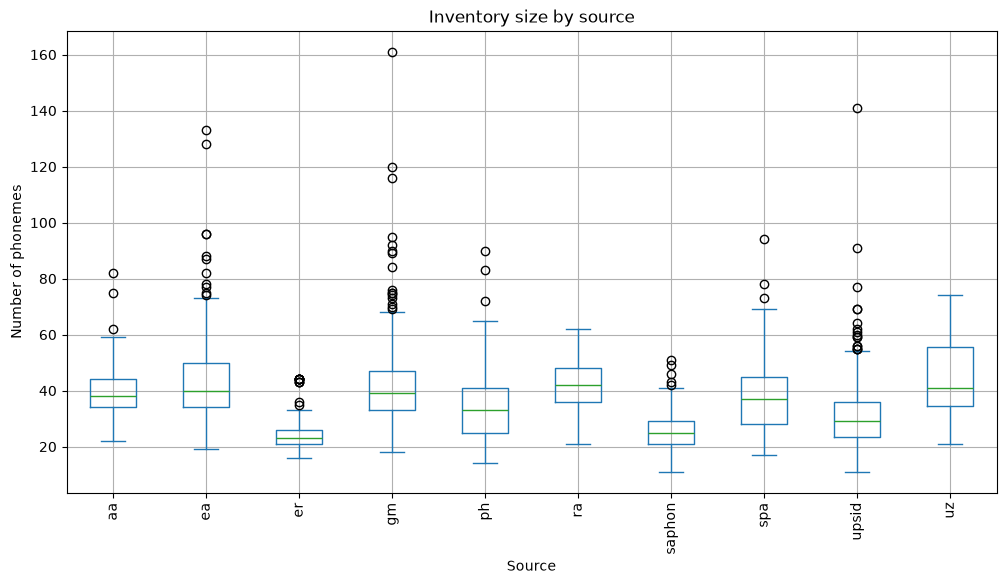

In [28]:
import matplotlib.pyplot as plt

source_sizes.pivot(
    columns="Source",
    values="PhonemeCount"
).plot(
    kind="box",
    rot=90,
    figsize=(12, 6)
)

plt.title("Inventory size by source")
plt.xlabel("Source")
plt.ylabel("Number of phonemes")
plt.grid(True)
plt.show()

The sources do not completely agree. Inventory sizes vary across sources: for example, the median is 23 phonemes for er and 25 for saphon, but 41 for uz and 42 for ra. If one source systematically reports larger inventories, then part of the difference we observe may come from the source itself rather than from the languages alone.

## Question 7

In [30]:
# Q7: Define vowels
# Keep all rows labelled as "vowel", regardless of the Marginal value
vowels = df_selected[df_selected["SegmentClass"] == "vowel"].copy()

In [31]:
# Test if the convolutional vowels are correctly identified
print(vowels["SegmentClass"].unique())
print(vowels["Marginal"].value_counts(dropna=False))

['vowel']
Marginal
False    18083
NaN       4058
True       120
Name: count, dtype: int64


I count as vowels all rows where SegmentClass == "vowel", regardless of the value of Marginal. This keeps the definition simple and includes all vowels listed in the database. However, it may also include vowels that are only marginal in a language. 

If Marginal == TRUE were excluded, the inventory would focus more on the core vowel system, but some marginal vowels would be removed. If rows with Marginal == NA were excluded, the analysis would avoid including vowels whose marginal status is unknown, but some valid vowels could also be lost.

## Question 8


Mean: 10.192307692307692


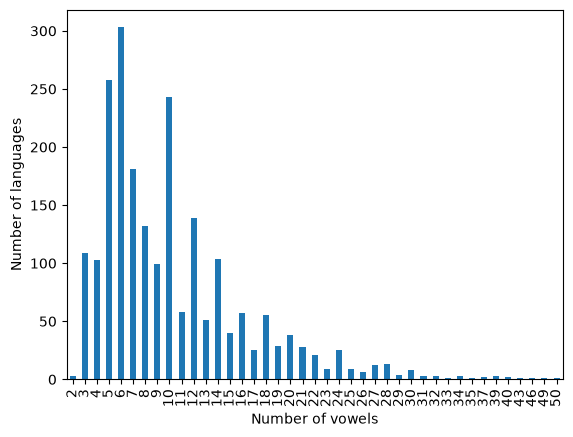

In [32]:
# Q8: Count the number of vowels in each language
vowel_counts = vowels.groupby("Glottocode")["Phoneme"].nunique()

print("Mean:", vowel_counts.mean())

vowel_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of vowels")
plt.ylabel("Number of languages")
plt.show()

The average vowel inventory size is about 10.2 vowels per language. The distribution is uneven: most languages have relatively small vowel inventories, with the highest frequencies around 5–10 vowels, while much larger inventories are increasingly rare.

## Question 9


These statistics are useful because the average gives a general idea of vowel inventory size across languages, but it can hide differences between languages. Examining the distribution shows which inventory sizes are most common, how much they vary, whether the distribution is skewed, and whether there are unusually large or small inventories.

## Question 10

In [ ]:
# Q10: Identify outliers using the interquartile range (IQR)
q1, q3 = vowel_counts.quantile([0.25, 0.75])
iqr = q3 - q1

outliers = vowel_counts[
    (vowel_counts < q1 - 1.5 * iqr) |
    (vowel_counts > q3 + 1.5 * iqr)
]

print("Lower bound:", q1 - 1.5 * iqr)
print("Upper bound:", q3 + 1.5 * iqr)
print("Number of outliers:", len(outliers))

Lower bound: -4.5
Upper bound: 23.5
Number of outliers: 99


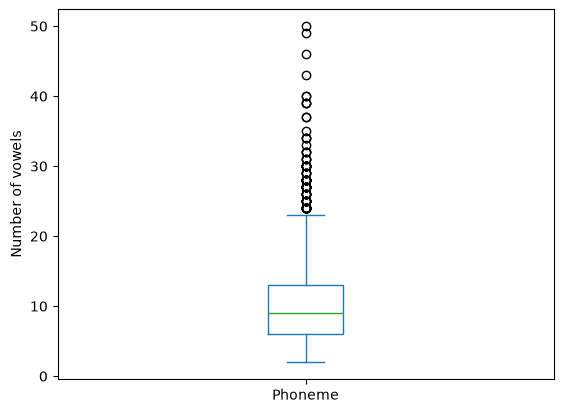

In [34]:
# Q10: Boxplot of vowel inventory sizes
vowel_counts.plot(kind="box")
plt.ylabel("Number of vowels")
plt.show()

I used the IQR method, where $Q_1$ is the 25th percentile and $Q_3$ is the 75th percentile. Values below $Q_1 - 1.5 \times IQR$ or above $Q_3 + 1.5 \times IQR$ are treated as outliers.

The lower and upper bounds were $-4.5$ and $23.5$. Since vowel inventory size cannot be negative, only the upper bound is relevant here. I found 99 outliers, meaning that 99 languages have 24 or more vowels. These languages have relatively large vowel inventories.

## Question 11

In [35]:
# Q11: Three most frequent vowels
vowel_frequency = vowels.groupby("Phoneme")["Glottocode"].nunique()
vowel_frequency.nlargest(3)

Phoneme
i    2059
u    1966
a    1922
Name: Glottocode, dtype: int64

The three most frequent vowels are /i/, /u/, and /a/. They occur in 2,059, 1,966, and 1,922 languages respectively.

## Question 12

In [36]:
# Q12: Proportion of languages containing /i/, /a/, and /u/
total_languages = vowels["Glottocode"].nunique()

for vowel in ["i", "a", "u"]:
    count = vowel_frequency[vowel]
    print(vowel, f"{count / total_languages:.1%}")

i 94.3%
a 88.0%
u 90.0%


/i/, /a/, and /u/ occur in 94.3%, 88.0%, and 90.0% of the languages. This shows that all three vowels are very common across languages and supports the idea of a basic vowel triangle. However, the proportions are not 100%, so they do not form an absolute universal if we only count the exact vowels /i/, /a/, and /u/.

## Question 13

In [37]:
# Q13: Define close equivalents of /i/, /a/, and /u/
import unicodedata

def base_vowel(x):
    x = unicodedata.normalize("NFD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    return x.replace("ː", "").replace("ˑ", "").replace("˞", "")


# Recompute the proportion of languages using the new criterion
for vowel in ["i", "a", "u"]:
    count = vowels[
        vowels["Phoneme"].apply(base_vowel) == vowel
    ]["Glottocode"].nunique()

    print(vowel, f"{count / total_languages:.1%}")

i 97.2%
a 93.2%
u 92.9%


For this question, I used AI to help with the Python implementation of this criterion. 
I treated a vowel as a close equivalent of /i/, /a/ or /u/ when removing all Unicode combining diacritics, as well as the length mark /ː/, the half-length mark /ˑ/, and rhoticity /˞/, reduced it to /i/, /a/ or /u/. For example, /ĩ/, /iː/ and /i˞/ were counted as close equivalents of /i/.

With this new criterion, the proportions increased to 97.2% for /i/, 93.2% for /a/, and 92.9% for /u/. The overall conclusion does not change, but the results give stronger support to the idea of a basic vowel triangle.

In [74]:
# Check the changes made by the new criterion
check_vowels = vowels[["Phoneme"]].copy()
check_vowels["BaseVowel"] = check_vowels["Phoneme"].apply(base_vowel)

check_vowels[
    check_vowels["Phoneme"] != check_vowels["BaseVowel"]
].drop_duplicates().head(30)

,Phoneme,BaseVowel
1580,aː,a
1581,e̞,e
1582,e̞ː,e
1586,iː,i
1595,o̞,o
1596,o̞ː,o
1603,uː,u
1633,ɑː,ɑ
1635,ɛː,ɛ
1645,oː,o


I then checked the output manually to make sure the rule worked as intended. For example, forms such as /aː/, /e̞/, /ə̃ː/ and /ĩː/ were reduced to /a/, /e/, /ə/ and /i/, respectively.

## Question 14

In [75]:
# Q14: Find languages that violate the first universal
# Select languages that have /i/, /a/, and /u/, or their close equivalents
has_i = set(vowels[vowels["Phoneme"].apply(base_vowel) == "i"]["Glottocode"])
has_a = set(vowels[vowels["Phoneme"].apply(base_vowel) == "a"]["Glottocode"])
has_u = set(vowels[vowels["Phoneme"].apply(base_vowel) == "u"]["Glottocode"])

violations = set(vowels["Glottocode"]) - (has_i & has_a & has_u)

print("Number of languages that violate the first universal:", len(violations))

Number of languages that violate the first universal: 296


In [86]:
# Inspect a few selected violations of the first universal
sample_violations = ["lush1252", "como1259", "cavi1250", "yess1239"]

vowels[
    vowels["Glottocode"].isin(sample_violations)
][
    ["Glottocode", "LanguageName", "Phoneme"]
].drop_duplicates()

,Glottocode,LanguageName,Phoneme
15554,lush1252,LUSHOOTSEED,a
15559,lush1252,LUSHOOTSEED,ə
15563,lush1252,LUSHOOTSEED,ɪ
15585,lush1252,LUSHOOTSEED,ʊ
21231,yess1239,YESSAN-MAYO,a
21232,yess1239,YESSAN-MAYO,ɒ
21233,yess1239,YESSAN-MAYO,ɜ
21235,yess1239,YESSAN-MAYO,ɨ
38261,como1259,Comox,a
38262,como1259,Comox,ə


In [ ]:
# Supplemental experiment with: add ɪ, ɑ, ʊ to the close equivalents
import unicodedata

def base_vowel_broad(x):
    x = unicodedata.normalize("NFD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = x.replace("ː", "").replace("ˑ", "").replace("˞", "")
    
    equivalents = {
        "ɪ": "i",
        "ɑ": "a",
        "ʊ": "u",
    }
    
    return equivalents.get(x, x)


# Recompute the proportion of languages using the new criterion
for vowel in ["i", "a", "u"]:
    count = vowels[
        vowels["Phoneme"].apply(base_vowel_broad) == vowel
    ]["Glottocode"].nunique()

    print(vowel, f"{count / total_languages:.1%}")

i 99.0%
a 98.5%
u 95.1%


In [77]:
# Select languages that have /i/, /a/, and /u/, or their close equivalents
has_i = set(vowels[vowels["Phoneme"].apply(base_vowel_broad) == "i"]["Glottocode"])
has_a = set(vowels[vowels["Phoneme"].apply(base_vowel_broad) == "a"]["Glottocode"])
has_u = set(vowels[vowels["Phoneme"].apply(base_vowel_broad) == "u"]["Glottocode"])

violations = set(vowels["Glottocode"]) - (has_i & has_a & has_u)

print("Number of languages that violate the first universal:", len(violations))

Number of languages that violate the first universal: 141


I found 296 languages that violate the first universal under my definition of close equivalents. I inspected several of them manually. In these selected inventories, Lushootseed has /a, ə, ɪ, ʊ/, Comox has /a, ə, ɛ, ɪ, o/, and Cavineña has /a, e, i, ʊ/. These languages therefore do not contain all three of /i/, /a/ and /u/ or their close equivalents under my criterion, although some contain similar vowels such as /ɪ/ or /ʊ/.

As a small additional check, I broadened the criterion further by also treating /ɪ/, /ɑ/ and /ʊ/ as close equivalents of /i/, /a/ and /u/. The proportions then increased to 99.0%, 98.5% and 95.1%, respectively, but 141 languages still violated the universal. For example, Yessan-Mayo still lacks the full /i, a, u/ pattern under this broader criterion.

Therefore, the data do not support an absolute universal. They support a statistical tendency.

## Question 15

In [84]:
# Q15: Inspect selected exceptions and check Marginal and Source information
vowels[
    vowels["Glottocode"].isin(sample_violations)
][["Glottocode", "LanguageName", "Phoneme", "Marginal", "Source"]].drop_duplicates()

,Glottocode,LanguageName,Phoneme,Marginal,Source
15554,lush1252,LUSHOOTSEED,a,False,upsid
15559,lush1252,LUSHOOTSEED,ə,False,upsid
15563,lush1252,LUSHOOTSEED,ɪ,False,upsid
15585,lush1252,LUSHOOTSEED,ʊ,False,upsid
21231,yess1239,YESSAN-MAYO,a,False,upsid
21232,yess1239,YESSAN-MAYO,ɒ,False,upsid
21233,yess1239,YESSAN-MAYO,ɜ,False,upsid
21235,yess1239,YESSAN-MAYO,ɨ,False,upsid
38261,como1259,Comox,a,False,ph
38262,como1259,Comox,ə,False,ph


Some exceptions seem to be artefacts, while others appear to be genuine counter-examples. For example, some of the cases from Q14 involved vowels such as /ɪ/ and /ʊ/, which are close to /i/ and /u/. When I also treated /ɪ/, /ɑ/ and /ʊ/ as close equivalents, the number of exceptions decreased from 296 to 141. However, some languages still remained exceptions. For example, Yessan-Mayo has only /a, ɒ, ɜ, ɨ/ in the selected inventory. I also checked the Marginal and Source information: in Lushootseed, Comox and Yessan-Mayo, all listed vowels have Marginal = False, while Cavineña has Marginal = NA. The examples also come from different sources, so the exceptions cannot all be explained by marginal phonemes or by a single source.

## Question 16

In [87]:
# Q16: Build the list of languages having at least one nasal vowel, at least one long vowel, and at least one front rounded vowel
nasal_languages = vowels[vowels["nasal"] == "+"]["Glottocode"].unique()
long_languages = vowels[vowels["long"] == "+"]["Glottocode"].unique()
front_rounded_languages = vowels[
    (vowels["front"] == "+") & (vowels["round"] == "+")
    ]["Glottocode"].unique()

In [88]:
print("Nasal vowel languages:", len(nasal_languages))
print("Long vowel languages:", len(long_languages))
print("Front rounded vowel languages:", len(front_rounded_languages))

Nasal vowel languages: 473
Long vowel languages: 821
Front rounded vowel languages: 173


## Question 17

In [ ]:
# Q17: feature-based test of implicational universals
feature_cols = list(vowels.loc[:, "tone":"click"].columns)

def test_implication(language_codes, marked_feature, ignored_features):
    """Return whether every marked vowel has a matching unmarked counterpart."""
    features_to_match = [
        f for f in feature_cols
        if f not in ignored_features
    ]

    results = []

    for code in language_codes:
        data = vowels[vowels["Glottocode"] == code]

        marked = data[data[marked_feature] == "+"]
        unmarked = data[data[marked_feature] == "-"]

        has_counterparts = all(
            unmarked[features_to_match]
            .eq(row[features_to_match])
            .all(axis=1)
            .any()
            for _, row in marked.iterrows()
        )

        results.append(has_counterparts)

    return results

# Nasal vowel -> oral vowel:
# only nasalisation may differ
nasal_results = test_implication(
    nasal_languages,
    marked_feature="nasal",
    ignored_features={"nasal"}
)

# Long or half-long vowel -> non-long vowel:
# both length-related features may differ
long_results = test_implication(
    long_languages,
    marked_feature="long",
    ignored_features={"long", "short"}
)

# /y/ -> /i/ and /u/
language_vowels = vowels.groupby("Glottocode")["Phoneme"].apply(set)

y_languages = vowels.loc[
    vowels["Phoneme"] == "y", "Glottocode"
].unique()

y_results = [
    {"i", "u"}.issubset(language_vowels[code])
    for code in y_languages
]

# Print the results of the tests
for name, results in [
    ("Nasal -> oral", nasal_results),
    ("Long/half-long -> non-long", long_results),
    ("/y/ -> /i/ and /u/", y_results)
]:
    tested = len(results)
    satisfying = sum(results)
    exceptions = results.count(False)

    print(
        f"{name}: "
        f"tested = {tested}, "
        f"satisfying = {satisfying}, "
        f"exceptions = {exceptions}, "
        f"proportion = {satisfying / tested:.1%}"
    )

Nasal -> oral: tested = 473, satisfying = 418, exceptions = 55, proportion = 88.4%
Long/half-long -> non-long: tested = 821, satisfying = 642, exceptions = 179, proportion = 78.2%
/y/ -> /i/ and /u/: tested = 108, satisfying = 97, exceptions = 11, proportion = 89.8%


For the nasal-to-oral implication, 88.4% of the relevant languages satisfied the condition, with 55 exceptions. For long or half-long vowels, 78.2% of the relevant languages had a corresponding non-long vowel, with 179 exceptions. For /y/, 89.8% of the languages also contained both /i/ and /u/, with 11 exceptions. Overall, all three implications are supported as strong statistical tendencies, but none of them is absolute.  

## Question 18

In [93]:
# Q18: 2 × 2 table for an implication A -> B
table = pd.DataFrame(
    [
        ["A +, B +", "A +, B -"],
        ["A -, B +", "A -, B -"]
    ],
    index=["A present", "A absent"],
    columns=["B present", "B absent"]
)

table

,B present,B absent
A present,"A +, B +","A +, B -"
A absent,"A -, B +","A -, B -"


For an implication “if A, then B”, the cell where A is present but B is absent must be empty or nearly empty, because these cases are exceptions to the implication. This is not a symmetric association because A → B does not imply B → A. Languages can have B without A and still satisfy the implication.

## Question 19

The first universal is somewhat better supported by PHOIBLE. Under my broader definition of close equivalents, where /ɪ/, /ɑ/ and /ʊ/ were also treated as equivalents of /i/, /a/ and /u/, only 141 of 2,184 languages were exceptions. The second universal also shows clear statistical tendencies, but the proportions were lower in some cases: 88.4% for nasal → oral, 78.2% for long → short, and 89.8% for /y/ → /i/ and /u/.   However, the second universal is more informative about the structure of vowel systems because it describes relationships between marked vowels and their simpler counterparts. The first universal mainly shows how common certain vowels are across languages.

## Question 20

In [151]:
# Q20: Construct a 2 × 2 contingency table for /i/ and /u/

has_i = vowels.groupby("Glottocode")["Phoneme"].apply(lambda x: "i" in set(x))
has_u = vowels.groupby("Glottocode")["Phoneme"].apply(lambda x: "u" in set(x))

table_iu = pd.crosstab(has_i, has_u)

table_iu.index = ["/i/ absent", "/i/ present"]
table_iu.columns = ["/u/ absent", "/u/ present"]

table_iu

,/u/ absent,/u/ present
/i/ absent,108,17
/i/ present,110,1949


## Question 21

In [95]:
# Q21: Chi-square test of independence
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_iu)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 852.7231224011905
p-value: 1.8601796897136457e-187


I applied a chi-square test of independence to the contingency table
for /i/ and /u/. The test was statistically significant,
$\chi^2(1) = 852.72$, $p < .001$. Therefore, the presence of /i/ and
/u/ is not independent in the PHOIBLE sample. The observed number of
languages containing both vowels is greater than expected under
independence.

## Question 22

In [96]:
# Q22: Compute mutual information for /i/ and /u/
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(has_i, has_u)

p_i = has_i.mean()
p_u = has_u.mean()
p_both = (has_i & has_u).mean()

print("Mutual information:", mi)
print("p(i, u):", p_both)
print("p(i) * p(u):", p_i * p_u)

Mutual information: 0.10537779343281989
p(i, u): 0.8923992673992674
p(i) * p(u): 0.848661678675415


The mutual information between /i/ and /u/ was 0.105 nats, indicating that the two vowels are not independent. To determine the direction of this relationship, I compared their observed co-occurrence with the value expected under independence. The observed probability that both vowels occur in the same language was $P(i=1, u=1) = 0.892$, compared with an expected probability of $P(i=1)P(u=1) = 0.849$. Since the observed probability is higher, /i/ and /u/ show a positive co-occurrence association across languages.

## Question 23

The two methods lead to the same conclusion. The chi-square test showed a significant association between /i/ and /u/, and the mutual information was above zero, also indicating dependence between the two vowels. The comparison of observed and expected co-occurrence probabilities further showed that /i/ and /u/ tend to co-occur.

## Question 24

In [97]:
# Q24: Build a 2 × 2 table for /i/ and a rare vowel /ɶ/
has_rare = vowels.groupby("Glottocode")["Phoneme"].apply(
    lambda x: "ɶ" in set(x)
)

table_rare = pd.crosstab(has_i, has_rare)

table_rare.index = ["/i/ absent", "/i/ present"]
table_rare.columns = ["/ɶ/ absent", "/ɶ/ present"]

table_rare

,/ɶ/ absent,/ɶ/ present
/i/ absent,124,1
/i/ present,2059,0


In [98]:
chi2, p_chi, dof, expected = chi2_contingency(table_rare)

print("Expected counts:")
print(expected)
print("Chi-square p-value:", p_chi)

Expected counts:
[[1.24942766e+02 5.72344322e-02]
 [2.05805723e+03 9.42765568e-01]]
Chi-square p-value: 0.05658198935272409


In [99]:
# Fisher's exact test
from scipy.stats import fisher_exact

odds_ratio, p_fisher = fisher_exact(table_rare)

print("Fisher p-value:", p_fisher)

Fisher p-value: 0.05723443223443223


I examined the association between /i/ and the rare vowel /ɶ/, which occurs in only one language in the selected sample. The expected counts for the two cells where /ɶ/ is present were 0.057 and 0.943, both far below the usual threshold of 5. Therefore, the assumptions of the chi-square test are violated.

The chi-square test gave $p = .0566$, whereas Fisher's exact test gave $p = .0572$. The two values are similar, and both are above .05, but Fisher's exact test is the appropriate result because it does not rely on large expected counts. At the 5% level, there is no statistically significant evidence of an association between /i/ and /ɶ/.

## Question 25

In [100]:
from itertools import combinations

n_languages = vowels["Glottocode"].nunique()

# Number of languages containing each vowel
vowel_freq = vowels.groupby("Phoneme")["Glottocode"].nunique()

# All vowels and all possible vowel pairs
n_vowels = len(vowel_freq)
n_pairs = n_vowels * (n_vowels - 1) // 2

print("Number of vowels:", n_vowels)
print("Number of vowel pairs/tests:", n_pairs)
print("Expected false positives at 5%:", 0.05 * n_pairs)

# Vowels attested in only one language
vowels_in_one_language = vowel_freq[vowel_freq == 1]
print("Vowels attested in one language:", len(vowels_in_one_language))

Number of vowels: 884
Number of vowel pairs/tests: 390286
Expected false positives at 5%: 19514.3
Vowels attested in one language: 489


In [101]:
# Keep vowels attested in at least 5% of languages
vowel_freq_5 = vowel_freq[vowel_freq / n_languages >= 0.05]

n_vowels_5 = len(vowel_freq_5)
n_pairs_5 = n_vowels_5 * (n_vowels_5 - 1) // 2

print("Vowels attested in at least 5% of languages:", n_vowels_5)
print("Number of pairs remaining:", n_pairs_5)

Vowels attested in at least 5% of languages: 30
Number of pairs remaining: 435


In [102]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

frequent_vowels = vowel_freq_5.index

vowel_presence_5 = (
    pd.crosstab(vowels["Glottocode"], vowels["Phoneme"])[frequent_vowels] > 0
)

p_values = []

for A, B in combinations(frequent_vowels, 2):
    table = pd.crosstab(vowel_presence_5[A], vowel_presence_5[B])
    p_values.append(chi2_contingency(table, correction=False).pvalue)

print("Significant before correction:", sum(p < 0.05 for p in p_values))

significant_BH = multipletests(p_values, alpha=0.05, method="fdr_bh")[0]
print("Significant after BH correction:", significant_BH.sum())

Significant before correction: 276
Significant after BH correction: 266


There were 884 distinct vowels, giving $(884 \times 883)/2 = 390{,}286$ possible vowel pairs. At a 5% significance level, about 19,514 significant results would be expected by chance alone if no real associations existed. This shows why testing many pairs without correction is problematic.

I also found that 489 vowels were attested in only one language, so association tests involving these vowels would be very unstable. Following the new criterion, I therefore kept only vowels occurring in at least 5% of languages. This left 30 vowels and 435 possible pairs.

Among these 435 pairs, 276 were significant before correction and 266 remained significant after Benjamini--Hochberg correction. The small reduction suggests that many of the detected associations remain statistically significant after controlling the false discovery rate, although further analysis is needed to determine whether they reflect genuine properties of vowel systems.

## Question 26

In [103]:
import numpy as np

effect_results = []

for A, B in combinations(frequent_vowels, 2):
    a = vowel_presence_5[A]
    b = vowel_presence_5[B]

    n11 = (a & b).sum()
    n10 = (a & ~b).sum()
    n01 = (~a & b).sum()
    n00 = (~a & ~b).sum()

    phi = (n11*n00 - n10*n01) / np.sqrt(
        (n11+n10)*(n01+n00)*(n11+n01)*(n10+n00)
    )

    table = pd.crosstab(a, b)
    p = chi2_contingency(table, correction=False).pvalue

    effect_results.append([A, B, phi, p])

effect_results = pd.DataFrame(
    effect_results,
    columns=["Vowel_A", "Vowel_B", "phi", "p_value"]
)

In [108]:
display(effect_results.sort_values("phi", ascending=False).head(10))
display(effect_results.sort_values("phi").head(10))

,Vowel_A,Vowel_B,phi,p_value
210,iː,uː,0.919424,0.0
116,eː,oː,0.892955,0.0
231,ĩ,ũ,0.889161,0.0
63,ã,ĩ,0.880239,0.0
141,ẽ,õ,0.864831,0.0
402,ɔ̃,ɛ̃,0.847744,0.0
433,ɪ,ʊ,0.844271,0.0
70,ã,ũ,0.832773,0.0
165,e̞,o̞,0.821918,0.0
35,aː,iː,0.821583,0.0


,Vowel_A,Vowel_B,phi,p_value
17,a,ɑ,-0.552487,5.349720e-147
201,i,ɪ,-0.359908,1.750514e-63
247,o,o̞,-0.353847,2.006238e-61
93,e,o̞,-0.343442,5.701703e-58
86,e,e̞,-0.336281,1.184032e-55
162,e̞,o,-0.304804,4.851452e-46
203,i,ʊ,-0.295088,2.910446e-43
16,a,æ,-0.261172,2.908186e-34
329,u,ʊ,-0.249108,2.530524e-31
327,u,ɪ,-0.209541,1.212211e-22


The ranking by effect size was more informative than the ranking by $p$-value, and the two rankings were not identical. Many $p$-values were extremely small and were displayed as 0 because of numerical underflow, so they did not distinguish the strength of the associations very well. In contrast, the $\phi$ coefficient showed both the direction and the strength of each association.

The strongest positive associations had very large $\phi$ values, for example about 0.92 for /iː/--/uː/ and 0.89 for /eː/--/oː/. This suggests that languages with one long vowel often contain several long vowels across different vowel qualities.

At the negative end of the ranking, several strong associations involved phonetically similar vowel symbols or different transcription variants. These may reflect differences in how sources transcribe similar vowel categories rather than true phonological avoidance between the vowels. This is consistent with the source differences observed earlier in Question 6.

## Question 27

In [115]:
import numpy as np

def shuffle_matrix(matrix, n_attempts=50000):
    x = matrix.copy()
    n_rows, n_cols = x.shape

    for _ in range(n_attempts):
        r1, r2 = np.random.choice(n_rows, 2, replace=False)
        c1, c2 = np.random.choice(n_cols, 2, replace=False)

        block = x[np.ix_([r1, r2], [c1, c2])]

        if np.array_equal(block, [[1, 0], [0, 1]]):
            x[np.ix_([r1, r2], [c1, c2])] = [[0, 1], [1, 0]]

        elif np.array_equal(block, [[0, 1], [1, 0]]):
            x[np.ix_([r1, r2], [c1, c2])] = [[1, 0], [0, 1]]

    return x

In [116]:
np.random.seed(42)
X = vowel_presence_5.astype(int).to_numpy()

null_phi = []

for _ in range(100):
    shuffled = shuffle_matrix(X)

    phi_values = []

    for i, j in combinations(range(X.shape[1]), 2):
        a = shuffled[:, i]
        b = shuffled[:, j]

        n11 = ((a == 1) & (b == 1)).sum()
        n10 = ((a == 1) & (b == 0)).sum()
        n01 = ((a == 0) & (b == 1)).sum()
        n00 = ((a == 0) & (b == 0)).sum()

        phi = (n11*n00 - n10*n01) / np.sqrt(
            (n11+n10)*(n01+n00)*(n11+n01)*(n10+n00)
        )

        phi_values.append(phi)

    null_phi.append(phi_values)

null_phi = np.array(null_phi)

In [117]:
observed_phi = effect_results["phi"].to_numpy()

p_null = (
    (np.abs(null_phi) >= np.abs(observed_phi)).sum(axis=0) + 1
) / (len(null_phi) + 1)

print("Associations beyond the null model:",
      (p_null < 0.05).sum())

Associations beyond the null model: 172


In [118]:
significant_null_BH = multipletests(
    p_null, alpha=0.05, method="fdr_bh"
)[0]

print("Associations after null-model BH correction:",
      significant_null_BH.sum())

Associations after null-model BH correction: 136


In [119]:
shuffled = shuffle_matrix(X)

print(np.all(X.sum(axis=1) == shuffled.sum(axis=1)))
print(np.all(X.sum(axis=0) == shuffled.sum(axis=0)))

True
True


I built a null model by randomly shuffling the vowel inventories while preserving both the number of vowels in each language and the overall frequency of each vowel. I used 100 randomizations with a fixed random seed (42), 50,000 attempted swaps per randomization. I verified that both row and column totals were unchanged after shuffling.

Compared with this null model, 172 of the 435 vowel pairs had associations stronger than expected by chance at the 5% level. After Benjamini–Hochberg correction, 136 associations remained significant. This is fewer than the 266 associations that survived correction under the ordinary independence test in Q25, suggesting that some of the earlier associations can be explained by vowel frequencies and inventory sizes alone.

## Question 28

The results show that vowel inventories contain systematic associations, but some associations found under a simple independence assumption can be explained by vowel frequencies and inventory sizes. After Benjamini--Hochberg correction, the number of significant associations fell from 266 under the ordinary independence test in Question 25 to 136 under the constrained null model in Question 27.

These associations are not the same as the implications tested in Section 3.1. A symmetric association shows that two vowels co-occur more or less often than expected, but it does not specify a direction. An implication such as $A \rightarrow B$ requires languages with $A$ but without $B$ to be rare. Therefore, a strong association alone does not establish an implicational universal.

## Question 29

In [122]:
# Q29: Load the languages.csv file and print its columns
languages = pd.read_csv("languages.csv")

print(languages.columns.tolist())

['ID', 'Name', 'Macroarea', 'Latitude', 'Longitude', 'Glottocode', 'ISO639P3code', 'Family_Glottocode', 'Family_Name']


In [123]:
# Merge language information with df_selected to check for missing macroarea and family information
language_info = df_selected[
    ["Glottocode", "LanguageName"]
].drop_duplicates("Glottocode")

language_info = language_info.merge(
    languages[
        ["Glottocode", "Macroarea", "Family_Name"]
    ],
    on="Glottocode",
    how="left"
)

print("Languages:", len(language_info))
print("Missing macroarea:", language_info["Macroarea"].isna().sum())
print("Missing family:", language_info["Family_Name"].isna().sum())

Languages: 2184
Missing macroarea: 23
Missing family: 93


In [124]:
# Count the number of languages in each family and macroarea
family_counts = language_info["Family_Name"].value_counts()
area_counts = language_info["Macroarea"].value_counts()

print("Top language families:")
display(family_counts.head(15))

print("Macroareas:")
display(area_counts)

Top language families:


Family_Name
Atlantic-Congo              420
Pama-Nyungan                253
Indo-European               146
Austronesian                110
Afro-Asiatic                107
Sino-Tibetan                 99
Tupian                       50
Arawakan                     43
Mande                        43
Austroasiatic                40
Dravidian                    33
Uralic                       32
Nilotic                      28
Nuclear Trans New Guinea     28
Cariban                      24
Name: count, dtype: int64

Macroareas:


Macroarea
Africa           714
Eurasia          448
Australia        343
South America    332
Papunesia        183
North America    141
Name: count, dtype: int64

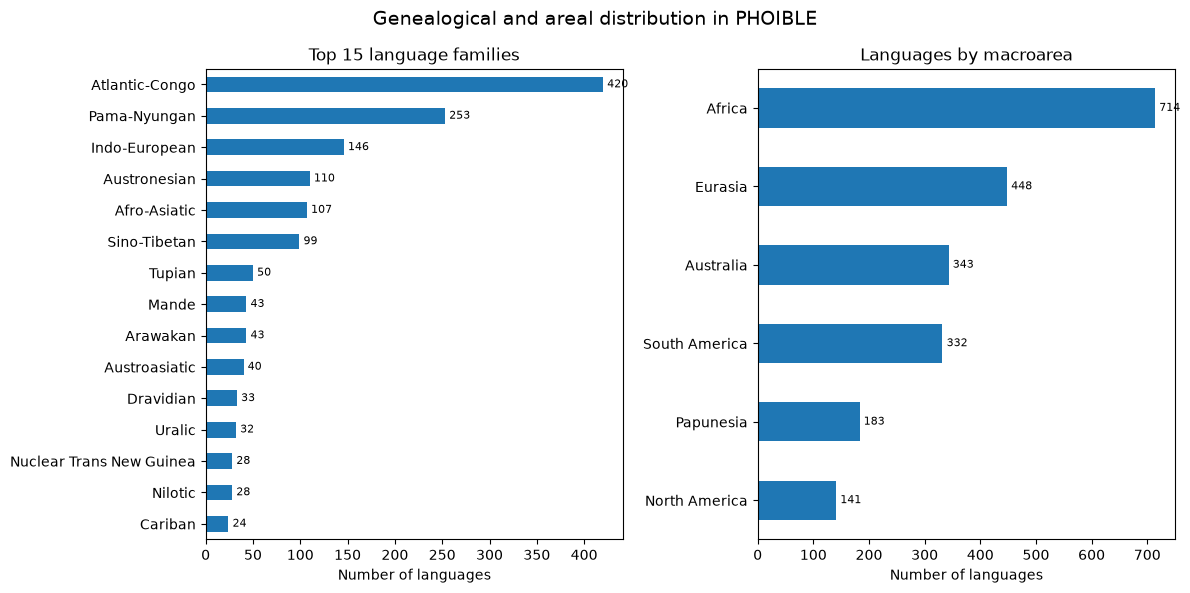

In [127]:
import matplotlib.pyplot as plt

# Plot the distribution of languages by family and macroarea
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

family_counts.head(15).sort_values().plot(
    kind="barh",
    ax=axes[0]
)
axes[0].set_title("Top 15 language families")
axes[0].set_xlabel("Number of languages")
axes[0].set_ylabel("")

area_counts.sort_values().plot(
    kind="barh",
    ax=axes[1]
)
axes[1].set_title("Languages by macroarea")
axes[1].set_xlabel("Number of languages")
axes[1].set_ylabel("")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=8)

fig.suptitle("Genealogical and areal distribution in PHOIBLE", fontsize=14)

plt.tight_layout()
plt.show()

The PHOIBLE v2.0 phoneme table does not include genealogical family or macroarea information. For Q29, I therefore used the PHOIBLE CLDF languages.csv metadata file (https://github.com/cldf-datasets/phoible/blob/master/cldf/languages.csv) and merged it with the selected PHOIBLE inventories using Glottocode. The metadata file provides Macroarea, Family_Glottocode, and Family_Name for the languages represented in PHOIBLE.

The merged dataset contained 2,184 languages. Family information was missing for 93 languages and macroarea information for 23. The most represented families were Atlantic-Congo, Pama-Nyungan, Indo-European, Austronesian, Afro-Asiatic, and Sino-Tibetan. The figure shows the distribution of the main language families and macroareas in the PHOIBLE sample.

## Question 30

In [128]:
# Q30: One random language per family
balanced_sample = (
    language_info
    .dropna(subset=["Family_Name"])
    .groupby("Family_Name", group_keys=False)
    .sample(n=1, random_state=42)
)

print("Number of families:", balanced_sample["Family_Name"].nunique())
print("Number of sampled languages:", len(balanced_sample))

Number of families: 176
Number of sampled languages: 176


In [129]:
balanced_vowels = vowels[
    vowels["Glottocode"].isin(balanced_sample["Glottocode"])
]

In [130]:
total_balanced = balanced_sample["Glottocode"].nunique()

for vowel in ["i", "a", "u"]:
    count = balanced_vowels[
        balanced_vowels["Phoneme"].apply(base_vowel) == vowel
    ]["Glottocode"].nunique()

    print(vowel, f"{count / total_balanced:.1%}")

i 96.0%
a 96.0%
u 92.0%


In [131]:
has_i_bal = set(
    balanced_vowels[
        balanced_vowels["Phoneme"].apply(base_vowel) == "i"
    ]["Glottocode"]
)

has_a_bal = set(
    balanced_vowels[
        balanced_vowels["Phoneme"].apply(base_vowel) == "a"
    ]["Glottocode"]
)

has_u_bal = set(
    balanced_vowels[
        balanced_vowels["Phoneme"].apply(base_vowel) == "u"
    ]["Glottocode"]
)

all_bal = set(balanced_sample["Glottocode"])

violations_bal = all_bal - (
    has_i_bal & has_a_bal & has_u_bal
)

print("Violations:", len(violations_bal))
print(
    "Proportion satisfying all three:",
    f"{1 - len(violations_bal) / total_balanced:.1%}"
)

Violations: 23
Proportion satisfying all three: 86.9%


I created a genealogically balanced sample by randomly selecting one language from each of the 176 language families with available family metadata (using a fixed random seed). Languages without family information were excluded from this sampling step. 

In this sample, 96.0% of languages contained /i/ or a close equivalent, 96.0% contained /a/ or a close equivalent, and 92.0% contained /u/ or a close equivalent. Overall, 86.9% of the sampled languages contained all three vowels; 23 languages did not. These proportions are similar to those in the full PHOIBLE sample. Thus, the basic vowel triangle remains a strong statistical tendency after reducing the influence of large language families. However, the exceptions show that it is not an absolute universal.

## Question 31

In [132]:
# Q31: Repeat the genealogically balanced sampling

n_repeats = 1000
results_q31 = []

for seed in range(n_repeats):

    sample = (
        language_info
        .dropna(subset=["Family_Name"])
        .groupby("Family_Name", group_keys=False)
        .sample(n=1, random_state=seed)
    )

    sample_vowels = vowels[
        vowels["Glottocode"].isin(sample["Glottocode"])
    ]

    total = len(sample)

    props = {}

    for vowel in ["i", "a", "u"]:
        langs = set(
            sample_vowels[
                sample_vowels["Phoneme"].apply(base_vowel) == vowel
            ]["Glottocode"]
        )
        props[vowel] = len(langs) / total

    has_i = set(
        sample_vowels[
            sample_vowels["Phoneme"].apply(base_vowel) == "i"
        ]["Glottocode"]
    )

    has_a = set(
        sample_vowels[
            sample_vowels["Phoneme"].apply(base_vowel) == "a"
        ]["Glottocode"]
    )

    has_u = set(
        sample_vowels[
            sample_vowels["Phoneme"].apply(base_vowel) == "u"
        ]["Glottocode"]
    )

    all_three = len(has_i & has_a & has_u) / total

    results_q31.append([
        props["i"],
        props["a"],
        props["u"],
        all_three
    ])

In [134]:
results_q31 = pd.DataFrame(
    results_q31,
    columns=["i", "a", "u", "all_three"]
)

display(results_q31.describe())

,i,a,u,all_three
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.961784,0.955517,0.901295,0.855886
std,0.009325,0.011628,0.014692,0.017337
min,0.931818,0.914773,0.852273,0.801136
25%,0.954545,0.948864,0.892045,0.846591
50%,0.960227,0.954545,0.903409,0.857955
75%,0.965909,0.965909,0.909091,0.869318
max,0.988636,0.988636,0.948864,0.909091


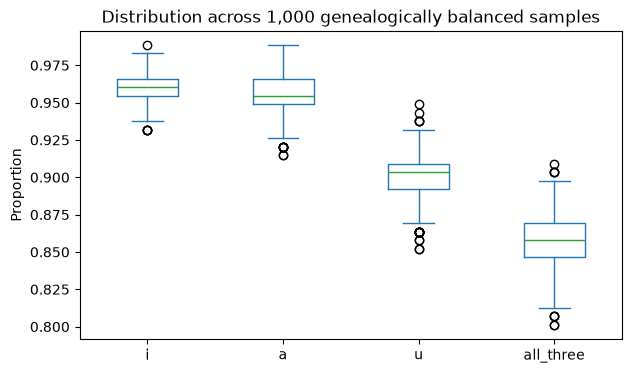

In [137]:
results_q31.plot(
    column=["i", "a", "u", "all_three"],
    figsize=(7, 4),
    kind="box"
)

plt.ylabel("Proportion")
plt.title("Distribution across 1,000 genealogically balanced samples")
plt.show()

I repeated the genealogically balanced sampling 1,000 times, selecting one language per family in each sample. The results were fairly stable across repetitions. The mean proportions were 96.2% for /i/, 95.6% for /a/, and 90.1% for /u/, with relatively small standard deviations. The proportion of languages containing all three averaged 85.6%, with a somewhat wider range from about 80.1% to 90.9%.

These results suggest that the conclusion is robust to genealogical balancing: /i/, /a/, and /u/ remain very common across families. However, the exact percentages depend on which language is selected from each family, especially for the proportion containing all three vowels. I would therefore report the result as a strong statistical tendency rather than as a fixed percentage or an absolute universal.

## Question 32

A statement such as “X% of the world’s languages have /i/” should be interpreted with caution. In this analysis, X% is the proportion of languages in the PHOIBLE sample that contain /i/, not necessarily the true proportion among all languages in the world. PHOIBLE is not a perfectly balanced sample, and languages from the same family are not independent observations. The genealogically balanced samples also showed that the exact proportion changes depending on which language is selected from each family. I would therefore describe X% as an estimate from this dataset, rather than an exact percentage for all world languages.

## Question 33

In [139]:
# Q33: compute support of itemset of single vowels
single_vowel_support = (
    vowels.groupby("Phoneme")["Glottocode"]
    .nunique()
    / vowels["Glottocode"].nunique()
).sort_values(ascending=False)

display(single_vowel_support.head(5))

Phoneme
i    0.942766
u    0.900183
a    0.880037
e    0.657051
o    0.641026
Name: Glottocode, dtype: float64

I grouped the vowel data by Phoneme, counted the number of distinct Glottocodes for each vowel, and divided each count by the total number of languages. I then sorted the resulting support values from highest to lowest.

## Question 34

In [140]:
# Q34: compute support of itemset of vowel pairs
from itertools import combinations

vowel_presence = pd.crosstab(
    vowels["Glottocode"],
    vowels["Phoneme"]
) > 0

vowel_pair_support = []

for A, B in combinations(vowel_presence.columns, 2):
    support = (vowel_presence[A] & vowel_presence[B]).mean()
    vowel_pair_support.append((A, B, support))

vowel_pair_support = pd.DataFrame(
    vowel_pair_support,
    columns=["Vowel_A", "Vowel_B", "Support"]
).sort_values("Support", ascending=False).reset_index(drop=True)

display(vowel_pair_support.head(10))

,Vowel_A,Vowel_B,Support
0,i,u,0.892399
1,a,i,0.842949
2,a,u,0.803114
3,e,i,0.646062
4,i,o,0.629121
5,e,u,0.619048
6,a,e,0.601648
7,e,o,0.600275
8,o,u,0.598901
9,a,o,0.582875


I converted the data into a language-by-vowel presence table, generated all unique vowel pairs, and calculated each pair's support as the proportion of languages containing both vowels.

## Question 35

In [141]:
# Q35: Define frequent itemsets using a 10% support threshold
min_support = 0.10

frequent_single_vowels = single_vowel_support[
    single_vowel_support >= min_support
]

frequent_vowel_pairs = vowel_pair_support[
    vowel_pair_support["Support"] >= min_support
]

print("Frequent single vowels:", len(frequent_single_vowels))
print("Frequent vowel pairs:", len(frequent_vowel_pairs))

Frequent single vowels: 23
Frequent vowel pairs: 115


I set the minimum support threshold to 0.10. This resulted in 23 frequent single-vowel itemsets and 115 frequent vowel-pair itemsets.

## Question 36

In [142]:
# Q36: inspect frequent vowel pairs
display(
    frequent_vowel_pairs
    .sort_values("Support", ascending=False)
    .head(20)
)

,Vowel_A,Vowel_B,Support
0,i,u,0.892399
1,a,i,0.842949
2,a,u,0.803114
3,e,i,0.646062
4,i,o,0.629121
5,e,u,0.619048
6,a,e,0.601648
7,e,o,0.600275
8,o,u,0.598901
9,a,o,0.582875


The most frequent vowel pairs were /i-u/, /a-i/, and /a-u/, with support values of about 0.89, 0.84, and 0.80. More generally, the highest-support pairs mainly involved the common vowels /i, a, u, e, o/, suggesting that frequent vowel pairs are largely built from vowels that are themselves very common across languages.

## Question 37

In [143]:
# Q37: confidence and lift for /e/ -> /o/

support_e = single_vowel_support["e"]
support_o = single_vowel_support["o"]

support_eo = vowel_pair_support.loc[
    (vowel_pair_support["Vowel_A"] == "e") &
    (vowel_pair_support["Vowel_B"] == "o"),
    "Support"
].iloc[0]

confidence_eo = support_eo / support_e
lift_eo = confidence_eo / support_o

print("Confidence (/e/ -> /o/):", confidence_eo)
print("Lift (/e/ -> /o/):", lift_eo)

Confidence (/e/ -> /o/): 0.913588850174216
Lift (/e/ -> /o/): 1.4251986062717767


For the rule /e/ → /o/, the confidence was about 0.91, meaning that about 91% of languages with /e/ also contained /o/. The lift was about 1.43, indicating that /e/ and /o/ co-occur substantially more often than expected under independence.

## Question 38

The most typical vowel combinations were /i-u/, /a-i/, and /a-u/, because they had the highest support values. For the rule /e/ → /o/, the confidence was about 0.91, meaning that around 91% of languages with /e/ also had /o/. The lift was about 1.43, which is greater than 1, indicating that /e/ and /o/ co-occur more often than expected under independence and therefore show a stronger association than expected by chance.

## Question 39

In [145]:
# Q39: binary language-by-vowel matrix
vowel_binary = pd.crosstab(
    vowels["Glottocode"],
    vowels["Phoneme"]
)

vowel_binary = (vowel_binary > 0).astype(int)

display(vowel_binary)

Phoneme,a,ae,ae̞,ae̞ˤ,ae̯,ai,ai̯,ai̯ː,ao,ao̞,...,ʌ̃,ʌ̃ː,ʌ̤,ʌ̤ː,ʏ,ʏi̯,ʏː,ʏ̃,ʏ̃ː,ˀy
Glottocode,,,,,,,,,,,,,,,,,,,,,
aari1239,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abar1238,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abau1245,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abid1235,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abip1241,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zoee1240,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zoog1238,1,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
zulg1242,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


I created a binary language-by-vowel matrix, where each row represents a language, each column represents a vowel, and each cell indicates presence (1) or absence (0). Positive counts were converted to 1, while zero counts remained 0.

## Question 40

In [150]:
%pip install mlxtend

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=28885) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [146]:
from mlxtend.frequent_patterns import apriori

# Q40: find frequent vowel pairs with Apriori
frequent_itemsets = apriori(
    vowel_binary.astype(bool),
    min_support=0.10,
    use_colnames=True,
    max_len=2
)

frequent_pairs_apriori = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) == 2
].sort_values("support", ascending=False)

# check that the results are consistent with the previous method
print(len(frequent_pairs_apriori))

115


I applied apriori() to the binary language-by-vowel matrix with a minimum support of 0.10 and kept only itemsets of size 2. This produced 115 frequent vowel pairs, matching the result from the previous manual method.

## Question 41

In [ ]:
# Q41: Save the results to a CSV file
frequent_pairs_apriori[["support", "itemsets"]].to_csv(
    "frequent_vowel_pairs.csv",
    index=False
)

I exported the 115 frequent vowel pairs identified by the Apriori algorithm, together with their support values, to a CSV file.

## Question 42

In [148]:
# Q42: association rules for /e/ -> /o/ and /i/ -> /u/
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0
)

# Select the two rules:
# /e/ -> /o/: if a language has /e/, does it also tend to have /o/?
# /i/ -> /u/: if a language has /i/, does it also tend to have /u/?
selected_rules = rules[
    (
        (rules["antecedents"] == frozenset(["e"])) &
        (rules["consequents"] == frozenset(["o"]))
    ) |
    (
        (rules["antecedents"] == frozenset(["i"])) &
        (rules["consequents"] == frozenset(["u"]))
    )
]

display(
    selected_rules[
        ["antecedents", "consequents", "confidence", "lift"]
    ]
)

,antecedents,consequents,confidence,lift
87,(e),(o),0.913589,1.425199
138,(i),(u),0.946576,1.051537


As shown in the results above, I selected two contrasting association rules: /e/ → /o/ and /i/ → /u/. The /e/ → /o/ rule has a much higher lift, while /i/ → /u/ has very high confidence but a lift close to 1. For /e/ → /o/, the confidence was about 0.91 and the lift about 1.43, showing that /e/ and /o/ co-occur more often than expected under independence. For /i/ → /u/, the confidence was about 0.95, but the lift was only about 1.05, so the association is only slightly stronger than expected under independence. This shows that high confidence does not necessarily mean a strong association, since the consequent vowel may already be very common.

## Question 43

In [149]:
# Q43: rerun Apriori on the whole phoneme inventory
whole_presence = pd.crosstab(
    df_selected["Glottocode"],
    df_selected["Phoneme"]
) > 0

whole_itemsets = apriori(
    whole_presence,
    min_support=0.10,
    use_colnames=True,
    max_len=2
)

whole_itemsets["length"] = whole_itemsets["itemsets"].apply(len)

whole_pairs = whole_itemsets[
    whole_itemsets["length"] == 2
].sort_values("support", ascending=False).reset_index(drop=True)

display(whole_pairs.head(20))

,support,itemsets,length
0,0.909799,"(m, i)",2
1,0.892399,"(i, u)",2
2,0.874542,"(m, k)",2
3,0.873626,"(m, j)",2
4,0.869048,"(m, u)",2
5,0.863095,"(k, i)",2
6,0.847985,"(i, j)",2
7,0.846154,"(m, a)",2
8,0.842949,"(a, i)",2
9,0.838370,"(k, p)",2


When I included the whole phoneme inventory, many of the highest-support pairs involved very common consonants such as /m/, /k/, /p/, /j/, and /w/. These consonants occur in many languages, so they tend to form high-support pairs with other common phonemes.

In the vowel-only analysis, the highest-support pairs were mainly /i-u/, /a-i/, and /a-u/. Since the aim here is to look at patterns within vowel systems, the vowel-only analysis is more informative for this question.

## Question 44

In [472]:
for threshold in [0.05, 0.10, 0.25]:
    itemsets = apriori(
        vowel_binary.astype(bool),
        min_support=threshold,
        use_colnames=True,
        max_len=2
    )

    pairs = itemsets[
        itemsets["itemsets"].apply(len) == 2
    ].sort_values("support", ascending=False)

    print(f"\nMinimum support = {threshold:.0%}")
    print("Number of frequent pairs:", len(pairs))
   


Minimum support = 5%
Number of frequent pairs: 198

Minimum support = 10%
Number of frequent pairs: 115

Minimum support = 25%
Number of frequent pairs: 33


As the minimum support threshold increased, the number of frequent vowel pairs decreased from 198 at 5% to 115 at 10% and 33 at 25%. A lower threshold includes more, less common vowel combinations, while a higher threshold keeps only the most frequent ones. I would choose the threshold based on the purpose of the analysis: a lower threshold is useful for exploring more possible patterns, whereas a higher threshold gives a smaller and more conservative set of frequent itemsets. This sensitivity shows that the results depend substantially on the chosen support threshold

## Question 45

From the rules calculated in Q42, I selected /i/ → /u/. This rule has a high confidence of about 0.95, but its lift is only about 1.05. The high confidence means that most languages with /i/ also have /u/, but /u/ itself is already very common across languages. Therefore, confidence alone can make the association look stronger than it really is. Lift takes the overall frequency of /u/ into account, and the value close to 1 shows that /i/ only slightly increases the probability of /u/ compared with what would be expected under independence.

## Question 46

The Apriori results partly recover the patterns tested earlier. The three highest-support vowel pairs were /i-u/ (0.892), /a-i/ (0.843), and /a-u/ (0.803). This is consistent with the earlier result that /i/, /a/, and /u/ are very common across languages. However, the earlier analysis also found counterexamples: even with the broader definition of close equivalents, 141 languages did not contain the full /i, a, u/ pattern. Therefore, Apriori supports this as a strong tendency, but not as an absolute universal.

The second set of universals is less directly recovered by Apriori. Earlier, nasal → oral was supported in 88.4% of cases, long → non-long in 78.2%, and /y/ → /i/ and /u/ in 89.8%. These are directional implications, while Apriori mainly identifies frequent co-occurrence patterns between individual vowels, so the two analyses are not exactly testing the same thing.

One additional pattern suggested by Apriori is the association between /e/ and /o/. For /e/ → /o/, the confidence was about 0.91 and the lift about 1.43, showing that they co-occur more often than expected under independence. Since this was not one of the original hypotheses, I would treat it as a new candidate pattern. I would test it separately with a contingency-table analysis and then check whether it remains after controlling for language family and data source

## Question 47

PHOIBLE is likely to underrepresent languages that are less well documented, especially small or endangered languages and languages from regions with less descriptive work. Better documented language families may therefore contribute disproportionately to the sample.

This could bias the universals if the missing languages have different vowel systems from the languages that are well represented. For example, if underrepresented languages are more likely to lack /i, a, u/ or to violate the implication patterns tested earlier, then the universals would look stronger in PHOIBLE than they really are. The opposite bias would also be possible if the missing languages followed the proposed patterns more closely.

## Question 48

**Universal 1: the /i, a, u/ vowel triangle.**

I now see this as a strong statistical tendency rather than an absolute universal. With the broader definition of close equivalents, /i/, /a/, and /u/ occurred in 99.0%, 98.5%, and 95.1% of languages, but 141 languages still lacked the complete pattern. The genealogically balanced samples gave a mean of about 85.6% for languages containing all three vowels, so the conclusion also depends somewhat on sampling. To settle the question more reliably, we would need a larger and more genealogically and geographically balanced sample, together with careful checking of the apparent counterexamples.


**Universal 2: highly marked vowels imply corresponding “simpler” vowels.**

This is also better treated as a statistical tendency. The implications were supported in 88.4% of languages for nasal → oral vowels, 78.2% for long/half-long → non-long vowels, and 89.8% for /y/ → /i/ and /u/. Since there are clear exceptions, none of these is absolute. A stronger test would require checking the exceptions individually and using a more balanced sample while controlling for language family and data source.

## Question 49

I think the answer depends on whether the proposed universal is absolute or statistical. For an absolute universal, one clear and reliable counterexample would be enough to show that it is wrong. For a statistical universal, a few exceptions would not be enough, but many well-documented counterexamples from unrelated languages would make the claim much less convincing. I would also check that the counterexamples are not caused by transcription differences, missing data, or source-specific analyses.